In [2]:
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
import os


In [3]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")


In [10]:
class ReviewState(TypedDict):
    book_summary: str
    all_reviews: Annotated[list[str], operator.add]  
    final_recommendation: str


In [12]:
def critic_review(state: ReviewState):
    """Literary Critic Persona - focuses on writing style"""
    system_message = SystemMessage(content="""You are a literary critic. You analyze books based on:
    1. Writing style and prose quality
    2. Character development
    3. Narrative structure
    4. Originality and literary merit
    5. Use of language and metaphors
    
    Provide a concise, professional review focusing on these aspects.""")
    
    human_message = HumanMessage(content=f"Book Summary: {state['book_summary']}")
    
    response = llm.invoke([system_message, human_message])
    
    return {"all_reviews": [f"LITERARY CRITIC REVIEW:\n{response.content}"]}


def parent_review(state: ReviewState):
    """Strict Parent Persona - focuses on moral values"""
    system_message = SystemMessage(content="""You are a strict parent concerned about moral values. Evaluate the book based on:
    1. Age-appropriateness
    2. Moral lessons and values
    3. Positive role models
    4. Content warnings (violence, language, etc.)
    5. Educational value
    
    Provide a concise review from a parent's perspective.""")
    
    human_message = HumanMessage(content=f"Book Summary: {state['book_summary']}")
    
    response = llm.invoke([system_message, human_message])
    
    return {"all_reviews": [f"PARENT REVIEW:\n{response.content}"]}

def teenager_review(state: ReviewState):
    """Teenager Persona - focuses on entertainment value"""
    system_message = SystemMessage(content="""You are a teenager evaluating a book. Focus on:
    1. Is it boring or exciting?
    2. Are characters relatable?
    3. Is it 'cool' or 'cringe'?
    4. Pacing and engagement level
    5. Would you recommend it to friends?
    
    Provide a concise, casual review using teen language.""")
    
    human_message = HumanMessage(content=f"Book Summary: {state['book_summary']}")
    
    response = llm.invoke([system_message, human_message])
    
    return {"all_reviews": [f"TEENAGER REVIEW:\n{response.content}"]}

def final_recommendation(state: ReviewState):
    """Analyzes all reviews and provides final recommendation"""
    
    # Combine all reviews
    all_reviews_text = "\n\n".join(state['all_reviews'])
    
    system_message = SystemMessage(content="""You are a book review aggregator. Analyze the three different reviews from different personas and provide:
    1. A brief summary of each persona's perspective
    2. Your overall assessment of the book
    3. Final recommendation: "MUST READ", "RECOMMENDED", "CONSIDER WITH CAUTION", or "SKIP"
    
    Format your response clearly with sections.""")
    
    human_message = HumanMessage(content=f"""Here are three reviews of the same book from different personas:

{all_reviews_text}

Book Summary: {state['book_summary']}

Provide your final recommendation based on these reviews.""")
    
    response = llm.invoke([system_message, human_message])
    
    return {"final_recommendation": response.content}



In [14]:
graph = StateGraph(ReviewState)

# Add all nodes
graph.add_node("critic_review", critic_review)
graph.add_node("parent_review", parent_review)
graph.add_node("teenager_review", teenager_review)
graph.add_node("final_recommendation", final_recommendation)

# Set up parallel execution for the three reviewers
graph.add_edge(START, "critic_review")
graph.add_edge(START, "parent_review")
graph.add_edge(START, "teenager_review")

# All three reviewers must complete before final recommendation
graph.add_edge("critic_review", "final_recommendation")
graph.add_edge("parent_review", "final_recommendation")
graph.add_edge("teenager_review", "final_recommendation")

graph.add_edge("final_recommendation", END)


workflow = graph.compile()


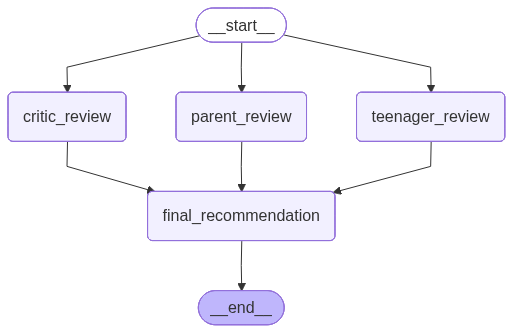

In [15]:
workflow


In [17]:
book_summary = """Harry Potter and the Philosopher's Stone tells the story of an orphaned boy, 
Harry Potter, who discovers on his eleventh birthday that he is a wizard. He is invited to attend 
Hogwarts School of Witchcraft and Wizardry, where he learns magic, makes friends, and uncovers 
a plot to steal the Philosopher's Stone, an object that grants immortality."""

initial_state = {
    "book_summary": book_summary,
    "all_reviews": [],  # Start with empty list
    "final_recommendation": ""
}

final_state = workflow.invoke(initial_state)
    

In [ ]:
final_state


{'book_summary': "Harry Potter and the Philosopher's Stone tells the story of an orphaned boy, \nHarry Potter, who discovers on his eleventh birthday that he is a wizard. He is invited to attend \nHogwarts School of Witchcraft and Wizardry, where he learns magic, makes friends, and uncovers \na plot to steal the Philosopher's Stone, an object that grants immortality.",
 'all_reviews': ["LITERARY CRITIC REVIEW:\nJ.K. Rowling's *Harry Potter and the Philosopher's Stone* marks a compelling debut into the fantasy genre, characterized by its accessible yet imaginative prose. The writing style is generally straightforward, effectively establishing the magical world and Harry's introduction to it without overly complex sentence structures, making it highly engaging for a broad readership.\n\nCharacter development, while foundational in this initial installment, is nonetheless promising. Harry's journey from an unloved orphan to a burgeoning wizard is compelling, though his personality is larg

In [19]:
final_state['all_reviews']


["LITERARY CRITIC REVIEW:\nJ.K. Rowling's *Harry Potter and the Philosopher's Stone* marks a compelling debut into the fantasy genre, characterized by its accessible yet imaginative prose. The writing style is generally straightforward, effectively establishing the magical world and Harry's introduction to it without overly complex sentence structures, making it highly engaging for a broad readership.\n\nCharacter development, while foundational in this initial installment, is nonetheless promising. Harry's journey from an unloved orphan to a burgeoning wizard is compelling, though his personality is largely defined by his reactions to his new environment. The supporting characters, particularly Ron and Hermione, are presented with distinct personalities that quickly endear them to the reader, hinting at the rich relationships to come.\n\nThe narrative structure adheres to a classic bildungsroman, charting Harry's growth and discovery. The pacing is well-managed, balancing the introduc